# Theoretical Copper profiles analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal as signal
import scipy.integrate as integrate
import torch
import torch.nn as nn


In [3]:
#grid parameters
Npts = 2401
pz_min = -12.5
pz_max = 12.5

# physical parameters
n_gauss = 5
fourier_order = 5
spin_asymm = 0.8

# experimental parameters
t_count = 5e5
res_fwhm = 0.12
err_scaling = 1

# random parameters
gauss_width_range = (0.3, 1.0)
gauss_amp_range = (0.05, 1.0)
parab_curv_range = (0.5, 1.5)
parab_offset_range = (1.5, 2.5)

fermi_window_width = 2
fermi_window_amp = 0.5
fermi_scale_range = (-2, -1.5)
fermi_coeff_range = 0.2

n_train = 200000
n_test = 50000

pz = np.linspace(pz_min, pz_max, Npts)
grid_spacing = np.abs(pz[1] - pz[0])
res_sigma = res_fwhm / (2 * np.sqrt(2 * np.log(2))) / grid_spacing


rng = np.random.default_rng()

In [11]:
def gaussian(x, width, amp):
    return (np.abs(amp) * np.exp(-0.5 * (x /(np.abs(width))) ** 2))

fermi_window = gaussian(pz, fermi_window_width, fermi_window_amp)

def parabola(x, vertex, curve, offset):
    return offset + curve * (x - vertex) ** 2


def fourier_series(x, a_coeffs, b_coeffs, frequency, n=0):

    result = a_coeffs[0] * np.ones_like(x)

    for i in range(1, n + 1):
            result += a_coeffs[i] * np.cos(i * frequency * x)
            if i <= len(b_coeffs):
                result += b_coeffs[i-1] * np.sin(i * frequency * x)

    return result

def noise(y):
    y_noisy = y + np.sqrt(np.abs(y)) * np.random.normal(0,0.0001,size=y.shape)
    return y_noisy

from Richardson_lucy_functions import gaussian_kernel_1D

def blur(y, sigma):
    kernel = gaussian_kernel_1D(size=31, sigma=sigma)
    y = signal.convolve(y, kernel, mode='same')

    return y

def normalise(y, x):
    area = integrate.simpson(y, x)
    y = (10 * y) / (area / 1)
    return y 


In [19]:
from pathlib import Path

# Define the model architecture
class DeblurUnet(nn.Module):
    def __init__(self):
        super(DeblurUnet, self).__init__()
        
        self.enc1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=7, padding=3),
            nn.ReLU(),)
        
        self.enc2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.enc3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec1 = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec2 = nn.Sequential(
            nn.Conv1d(256, 64, kernel_size=5, padding=2),
            nn.ReLU(),)
        
        self.dec3 = nn.Sequential(
            nn.Conv1d(128, 64, kernel_size=5, padding=2),
            nn.ReLU(),)

        self.final = nn.Conv1d(64, 1, kernel_size=7, padding=3)        
    
    def forward(self, x):
        x_input = x.unsqueeze(1)
        e1 = self.enc1(x_input)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        d1 = self.dec1(e3)
        d2 = self.dec2(torch.cat([d1, e2], dim=1))
        d3 = self.dec3(torch.cat([d2, e1], dim=1))
        output = self.final(d3)
        output = output.squeeze(1)
        output = x + 0.1 * output
        return output

# Load the model
model = DeblurUnet()
model_path = Path(r'c:\Users\Jpjha\OneDrive\Desktop\Decon by ML\Code\U-net.pth')
model.load_state_dict(torch.load(model_path))

C:\Users\Jpjha\AppData\Local\Temp\ipykernel_11680\598925365.py:50: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


<All keys matched successfully>

(1201,)


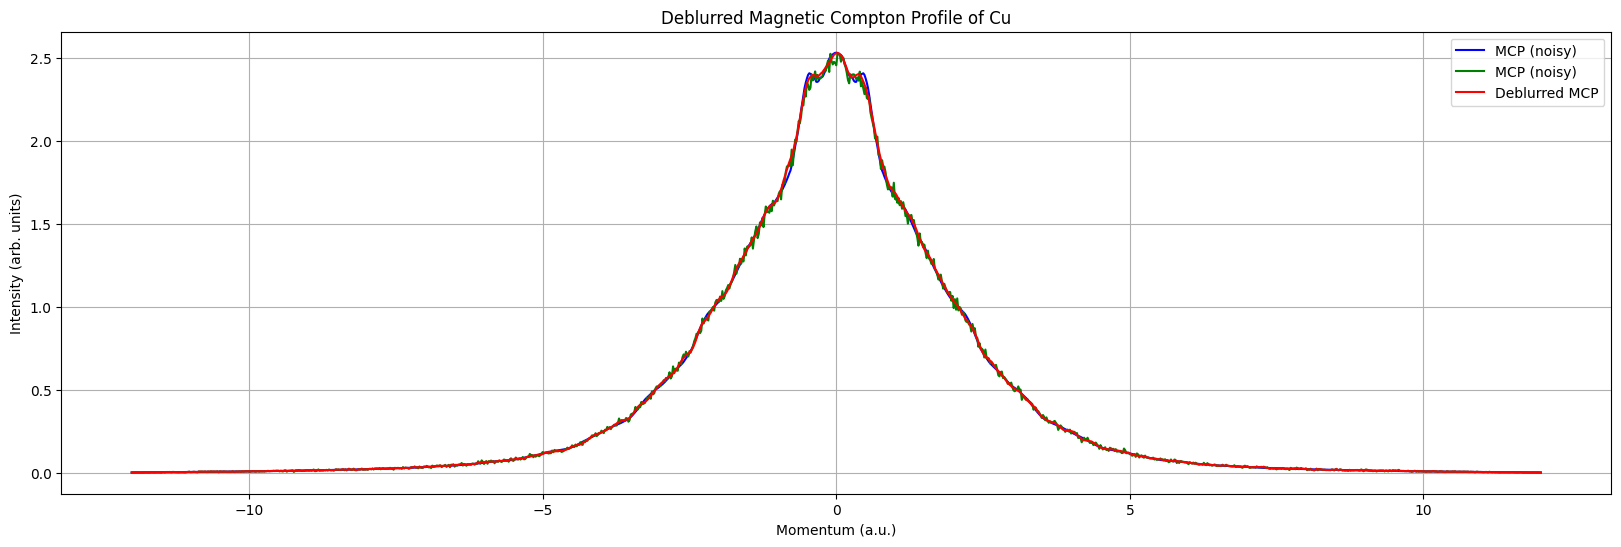

In [27]:
cu1 = np.loadtxt('Cu_Magnetic_Compton/I_EMD1D.OUT_SD_1', comments = '%')
cu12 = np.loadtxt('Cu_Magnetic_Compton/I_EMD1D.OUT_SD_18', comments = '%')

x1 = cu1[:,0]
y_1 = cu1[:,1] 

x12= cu12[:,0]
y_12 = cu12[:,1]

mcp = y_1 - 0.8 * y_12

mcp = normalise(mcp, x1)

y1blur = blur(y_1, res_sigma)
y12blur = blur(y_12, res_sigma)

y1noise = noise(y1blur)
y12noise = noise(y12blur)

mcp_bn = y1noise - 0.8 * y12noise
mcp_bn = normalise(mcp_bn, x1)

print(x1.shape)


blur_tensors_100 = torch.tensor(mcp_bn, dtype=torch.float32).unsqueeze(0)

model.eval()
with torch.no_grad():
    deblurred_100 = model(blur_tensors_100).squeeze(0).numpy()

plt.figure(figsize=(20,6))
plt.plot(x1, mcp, label='MCP (noisy)', color='blue')
plt.plot(x1, mcp_bn, label='MCP (noisy)', color='green')
plt.plot(x1, deblurred_100, label='Deblurred MCP', color='red')
plt.xlabel('Momentum (a.u.)')
plt.ylabel('Intensity (arb. units)')
plt.title('Deblurred Magnetic Compton Profile of Cu')
plt.legend()
plt.grid()
plt.show()

In [28]:
# compute reduced chi-squared comparing deblurred profile with original mcp (here mcp_bn)
# assume constant uncertainty (sigma) -> cancels; use dof = N-1
residuals  = mcp_bn - deblurred_100
dof        = residuals.size - 1
# if you know sigma, replace 1.0 with sigma**2 or an array of variances
chi2_red   = np.sum(residuals**2) / dof

print(f"reduced chi-squared = {chi2_red:.6e}")

#compute mean absolute error (MAE)
mae = np.mean(np.abs(residuals))
print(f"mean absolute error = {mae:.6e}")


reduced chi-squared = 1.743340e-04
mean absolute error = 6.936619e-03
